# 파이토치 훅 — 예제 노트북

심화 학습 자료 [`README.md`](README.md)의 모든 코드와 연습 문제 풀이를 담았다.

- 8장 8-2절과 8-3절의 모델을 다시 정의해 **이 노트북 하나만으로 실행**할 수 있게 했다.
- 학습이 필요한 부분은 최소한으로 줄였다. 대부분의 셀은 몇 초 안에 끝난다.
- 절 번호는 `README.md`와 같다.

## 준비 — 환경 설정, 데이터, 모델

In [1]:
# 환경 설정 (code_reference 모듈 임포트 경로와 시각화 설정)
import sys
sys.path.append('../../')

from code_reference import common
from code_reference import visualize as viz

common.set_korean_plot_env()
viz.configure(save_grayscale=False)

SEED = 42
common.set_seed(SEED, deterministic=True)
device = common.get_device()

CUDA를 사용합니다.


In [2]:
# CIFAR-10 데이터로더 (8장 예제와 같은 구성, 증강 없음)
import torch
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

data_root = '../../download'
CIFAR_MEAN = (0.5, 0.5, 0.5)
CIFAR_STD = (0.5, 0.5, 0.5)
BATCH_SIZE = 64

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

full_set = datasets.CIFAR10(root=data_root, train=True,
                            download=True, transform=transform)
test_set = datasets.CIFAR10(root=data_root, train=False,
                            download=True, transform=transform)

common.set_seed(SEED, deterministic=True)
train_set, valid_set = random_split(full_set, [40000, 10000])

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_set, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

print(f'훈련 {len(train_set)}, 검증 {len(valid_set)}, 평가 {len(test_set)}')

훈련 40000, 검증 10000, 평가 10000


In [3]:
# 8장의 모델 세 가지 ([코드 8-1], [코드 8-3], 5-3절 모델)
import torch.nn as nn


class ConvBlock(nn.Module):
    """합성곱, ReLU 활성화 함수, 최대 풀링으로 구성된 합성곱 블록"""

    def __init__(self, in_channels, out_channels,
                 kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, stride, padding),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.conv_block(x)


class MiniAlexNet(nn.Module):
    """5-3절의 CIFAR10ConvClassifier와 같은 구조(8장의 베이스라인)"""

    def __init__(self, num_classes=10):
        super().__init__()
        # 5x5 필터로 수용 영역을 빠르게 확장
        self.conv_block_1 = ConvBlock(3, 16, kernel_size=5, stride=1, padding=2)
        # 3x3 필터로 특징 추출
        self.conv_block_2 = ConvBlock(16, 32, kernel_size=3, stride=1, padding=1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 8 * 8, 256), nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.conv_block_1(x)
        x = self.conv_block_2(x)
        x = self.classifier(x)
        return x


class MiniVGGNet(nn.Module):
    """[코드 8-1]"""

    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )

        self.features = nn.Sequential(
            vgg_block(3, 32), vgg_block(32, 64), vgg_block(64, 128))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128), nn.ReLU(),
            nn.Dropout(p=0.5),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


class MiniVGGNetBN(nn.Module):
    """[코드 8-3]"""

    def __init__(self, num_classes=10):
        super().__init__()

        def vgg_block(in_channels, out_channels):
            return nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.Conv2d(out_channels, out_channels, kernel_size=3,
                          padding=1, bias=False),
                nn.BatchNorm2d(out_channels),
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2, stride=2),
            )

        self.features = nn.Sequential(
            vgg_block(3, 32), vgg_block(32, 64), vgg_block(64, 128))
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 128), nn.ReLU(),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print('모델 정의 완료')

모델 정의 완료


---

## 2. 훅의 세 단계 — 정의, 등록, 제거

### [코드 1] 계층의 입력과 출력 데이터의 평균과 표준편차를 출력하는 훅 함수

In [4]:
# 데이터가 계층을 통과할 때 전후 데이터의 평균과 표준편차를 계산해 출력
#   module: 훅을 등록할 계층
#   inputs: 계층으로 입력된 텐서
#     여러 계층의 출력이 입력되는 경우를 고려한 튜플 형태
#   output: 계층이 출력하는 텐서
#   (register_forward_hook 메서드로 훅을 등록하는 경우)
def data_inspect_hook(module, inputs, output):
    # 계층 입력 데이터의 평균과 표준편차
    # 연결된 이전 계층이 하나뿐이므로 inputs[0]만 계산
    input_mean = inputs[0].mean().item()
    input_std = inputs[0].std().item()
    # 계층 출력 데이터의 평균과 표준편차
    output_mean = output.mean().item()
    output_std = output.std().item()
    # 계층 통과 전후의 평균과 표준편차 출력
    print(f' {input_mean:.2f}({input_std:.2f}) -> {output_mean:.2f}({output_std:.2f})')

### 2.3 등록할 계층에 접근하기

In [5]:
# 방법 1 - 인덱싱: features의 첫 번째 VGG 블록의 두 번째 계층
model = MiniVGGNetBN()
target_layer = model.features[0][1]
print('인덱싱:', target_layer)

# 방법 2 - named_modules(): 계층이 많은 모델에서 훨씬 안전하다
print()
print('배치 정규화 계층의 이름')
for name, module in model.named_modules():
    if isinstance(module, nn.BatchNorm2d):
        print(f'  {name:16s} {module}')

인덱싱: BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)

배치 정규화 계층의 이름
  features.0.1     BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  features.0.4     BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  features.1.1     BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  features.1.4     BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  features.2.1     BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  features.2.4     BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)


### [코드 2] 모델의 첫 번째 배치 정규화 계층에 훅 등록

In [6]:
# 훅을 등록할 모델
model = MiniVGGNetBN()

# 훅을 추가할 계층: model.features의 첫 번째 VGG 블록의 두 번째 계층
target_layer = model.features[0][1]

# 훅 등록: register_forward_hook은 순전파에서 데이터가 target_layer를 통과할 때 실행
hook_handle = target_layer.register_forward_hook(data_inspect_hook)
print('훅 핸들:', hook_handle)

훅 핸들: <torch.utils.hooks.RemovableHandle object at 0x79ae1aae6780>


---

## 3. 순전파 훅으로 배치 정규화 관찰하기

### [코드 4] 모드에 따른 배치 정규화 훅 실행 결과

In [7]:
# 데이터가 target_layer(첫 번째 배치 정규화 계층)를 지날 때
# 배치 정규화 전후의 평균과 표준편차를 출력하는 data_inspect_hook() 함수가 자동 실행
print('배치 정규화 전 평균(표준편차) --> 배치 정규화 후 평균(표준편차)')
print('학습 모드')
model.train()
for i, (inputs, targets) in enumerate(train_loader):
    # 5개의 배치 입력에 대해서 확인
    if i == 5:
        break
    output = model(inputs)              # 순전파 발생 -> 훅 실행

# 훅은 모드와 무관하게 작동하므로 평가 모드에서도 전후의 평균과 표준편차를 출력하지만
# 배치 정규화는 학습 모드와 평가 모드에서 다른 방식으로 동작하므로 출력 결과는 다름
print('평가 모드')
model.eval()
for i, (inputs, targets) in enumerate(train_loader):
    output = model(inputs)
    break

배치 정규화 전 평균(표준편차) --> 배치 정규화 후 평균(표준편차)
학습 모드
 0.00(0.28) -> 0.00(1.00)
 0.00(0.30) -> -0.00(1.00)
 0.01(0.27) -> 0.00(1.00)


 0.02(0.29) -> -0.00(1.00)


 0.02(0.28) -> 0.00(1.00)
평가 모드
 0.01(0.29) -> 0.00(0.35)


### [코드 3] 등록한 훅 제거

In [8]:
# 훅 핸들의 remove() 메서드로 제거
hook_handle.remove()

# 제거 후에는 순전파를 해도 훅이 실행되지 않는다
print('훅 제거 후 순전파 (아무것도 출력되지 않아야 한다)')
model.eval()
with torch.no_grad():
    model(inputs)
print('-> 출력 없음 확인')

훅 제거 후 순전파 (아무것도 출력되지 않아야 한다)
-> 출력 없음 확인


### 2.4 훅 제거를 빠뜨리면 — 메모리 누수 확인

`detach()` 없이 출력을 모으면 연산 그래프까지 함께 붙잡힌다. 실제로 확인해 보자.

In [9]:
# detach() 유무에 따른 차이
model = MiniVGGNetBN()
model.train()
inputs, _ = next(iter(train_loader))

for use_detach in (False, True):
    collected = []

    def hook(module, hook_inputs, output):
        collected.append(output.detach() if use_detach else output)

    handle = model.features[0][1].register_forward_hook(hook)
    out = model(inputs)
    handle.remove()

    tensor = collected[0]
    label = 'detach() 사용' if use_detach else 'detach() 없음'
    # grad_fn이 남아 있으면 연산 그래프가 함께 붙잡혀 있다는 뜻
    print(f'{label:14s} grad_fn={tensor.grad_fn}, '
          f'연산 그래프 유지={tensor.grad_fn is not None}')

detach() 없음    grad_fn=<NativeBatchNormBackward0 object at 0x79ae099cb1f0>, 연산 그래프 유지=True
detach() 사용    grad_fn=None, 연산 그래프 유지=False


---

## 4. 역전파 훅으로 기울기 관찰하기

### [코드 5] 역전파로 전달된 기울기 신호의 정보를 출력하는 훅 함수

In [10]:
# 역전파에서 뒤 계층에서 전달된 기울기 신호(grad_outputs)의 최댓값 및 노름을 출력
# module: 훅을 등록할 계층
# grad_inputs: 앞 계층으로 전달할 기울기 신호(여러 계층으로 전달할 경우를 고려한 튜플 형태)
# grad_outputs: 뒤 계층에서 전달된 기울기 신호(여러 계층에서 전달될 경우를 고려한 튜플 형태)
#               (register_full_backward_hook 메서드로 훅을 등록하는 경우)
# 훅 등록 메서드에 따라 사용하지 않는 인자도 자리를 채워야 함(module과 grad_inputs)
def gradient_hook(module, grad_inputs, grad_outputs):
    # 절댓값의 최댓값: 기울기 소실 또는 폭주 확인
    grad_max = grad_outputs[0].abs().max().item()
    # 노름: 벡터 또는 텐서의 크기 지표(텐서의 norm() 메서드 사용)
    grad_norm = grad_outputs[0].norm().item()
    print(f' 최댓값: {grad_max:.6f}, 노름: {grad_norm:.6f}')

### [코드 6] 훅을 통한 기울기 신호 검사

In [11]:
import warnings

# 검사 대상 모델: MiniVGGNetBN
common.set_seed(SEED, deterministic=True)
model_vggbn = MiniVGGNetBN()
# 훅을 등록할 계층
conv_layers = []
# features[i][j]: (i + 1)번째 VGG 블록의 (j + 1)번째 계층
# 계층은 Conv2d(0) -> BatchNorm2d -> ReLU -> Conv2d(3) -> BatchNorm2d -> ReLU -> MaxPool2d 순서
conv_layers.append(model_vggbn.features[0][0])  # 첫 번째 블록의 첫 번째 합성곱
conv_layers.append(model_vggbn.features[1][0])  # 두 번째 블록의 첫 번째 합성곱(3번째)
conv_layers.append(model_vggbn.features[2][3])  # 세 번째 블록의 두 번째 합성곱(마지막)

# 역전파에서 계층의 기울기가 계산될 때 호출되는 훅 등록
# 리스트에 모으면 훅을 일괄 제거할 수 있음
handles = []
for layer in conv_layers:
    handle = layer.register_full_backward_hook(gradient_hook)
    handles.append(handle)

# 첫 번째 배치의 역전파만 확인(최적화 없이 backward()만으로 역전파 진행)
inputs, targets = next(iter(train_loader))
criterion = nn.CrossEntropyLoss()
print('모델 MiniVGGNetBN (출력층에 가까운 계층부터 출력된다)')
model_vggbn.train()
with warnings.catch_warnings():
    # 첫 번째 합성곱 계층은 grad_inputs가 None이라 경고가 나온다(본문 참고)
    warnings.simplefilter('ignore')
    output = model_vggbn(inputs)
    loss = criterion(output, targets)
    loss.backward()

# 리스트에 저장해 둔 훅 핸들을 사용해 훅 일괄 제거
for handle in handles:
    handle.remove()

모델 MiniVGGNetBN (출력층에 가까운 계층부터 출력된다)


 최댓값: 0.001198, 노름: 0.077998
 최댓값: 0.000961, 노름: 0.103042
 최댓값: 0.004224, 노름: 0.375917


### [표 2] 세 모델의 합성곱 계층 위치별 기울기 노름

In [12]:
# 세 모델의 합성곱 계층별 손실 기울기 노름을 한 번에 측정한다
def measure_grad_norms(model_class, layer_picker, label):
    common.set_seed(SEED, deterministic=True)
    model = model_class()
    layers = layer_picker(model)
    norms = {}

    def make_hook(index):
        def hook(module, grad_inputs, grad_outputs):
            norms[index] = grad_outputs[0].norm().item()
        return hook

    handles = [layer.register_full_backward_hook(make_hook(i))
               for i, layer in enumerate(layers)]
    model.train()
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        loss = nn.CrossEntropyLoss()(model(inputs), targets)
        loss.backward()
    for handle in handles:
        handle.remove()
    return [norms[i] for i in range(len(layers))]


alex_norms = measure_grad_norms(
    MiniAlexNet,
    lambda m: [m.conv_block_1.conv_block[0], m.conv_block_2.conv_block[0]],
    'MiniAlexNet')
vgg_norms = measure_grad_norms(
    MiniVGGNet,
    lambda m: [m.features[0][0], m.features[1][0], m.features[2][2]], 'MiniVGGNet')
vggbn_norms = measure_grad_norms(
    MiniVGGNetBN,
    lambda m: [m.features[0][0], m.features[1][0], m.features[2][3]], 'MiniVGGNetBN')

rows = ['1', '3', '마지막']
print(f"{'합성곱 계층 순서':<16}{'MiniAlexNet':>14}{'MiniVGGNet':>14}{'MiniVGGNetBN':>16}")
print('-' * 60)
alex_col = [alex_norms[0], None, alex_norms[1]]
for i, row in enumerate(rows):
    a = f'{alex_col[i]:.6f}' if alex_col[i] is not None else '-'
    print(f'{row:<16}{a:>14}{vgg_norms[i]:>14.6f}{vggbn_norms[i]:>16.6f}')

합성곱 계층 순서          MiniAlexNet    MiniVGGNet    MiniVGGNetBN
------------------------------------------------------------
1                     0.014146      0.000367        0.375917
3                            -      0.001840        0.103042
마지막                   0.030857      0.028501        0.077998


측정값은 모델의 초기 가중치(시드)에 따라 조금씩 달라지지만, **경향은 언제나 같다.**

- `MiniVGGNet`은 입력에 가까울수록 노름이 급격히 작아진다(기울기 소실).
- `MiniVGGNetBN`은 오히려 첫 번째 합성곱 계층의 노름이 가장 크다.

---

## 5. 사례 연구 — 8-3절의 배치 정규화 부작용 실험

### [코드 7] 배치 정규화의 부작용을 실험하기 위한 모델

In [13]:
# 배치 정규화를 num_blocks회 반복하는 단순한 합성곱 모델
#   배치 정규화의 부작용을 확인하는 것이 목적이며, 성능이 좋은 모델을 만드는 것이 아님
class StackedConvBN(nn.Module):
    def __init__(self, num_blocks, channels=16):
        super().__init__()
        # 첫 합성곱으로 채널 수를 channels로 맞춤
        layers = [
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        ]
        # 이후 num_blocks - 1회 반복해 동일 채널 합성곱 + 배치 정규화 블록 추가
        for _ in range(num_blocks - 1):
            layers.append(nn.Conv2d(channels, channels, 3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(channels))
            layers.append(nn.ReLU())
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)


# 지정한 수만큼 합성곱 계층이 만들어지는지 확인
for n in (12, 48, 96):
    m = StackedConvBN(n)
    count = sum(1 for mod in m.modules() if isinstance(mod, nn.Conv2d))
    print(f'StackedConvBN({n}): 합성곱 계층 {count}개')

StackedConvBN(12): 합성곱 계층 12개
StackedConvBN(48): 합성곱 계층 48개
StackedConvBN(96): 합성곱 계층 96개


### [코드 8] 두 입력에 대한 출력의 유클리드 거리와 코사인 유사도

In [14]:
import torch.nn.functional as F


@torch.no_grad()
def measure_similarity(model, x_a, x_b):
    model.train()
    # 두 입력 텐서를 묶어서 마치 하나의 배치인 것처럼 모델에 입력
    #   배치 정규화는 배치 단위 통계를 사용해 정규화하므로,
    #   학습에서 배치마다 입력이 달라지는 상황과 같은 조건이 됨
    outputs = model(torch.cat([x_a, x_b], dim=0))
    y_a = outputs[0].flatten()
    y_b = outputs[1].flatten()
    # 거리: 두 출력 텐서의 노름(유클리드 거리)
    dist = (y_a - y_b).norm().item()
    # 유사도: 코사인 유사도
    cos = F.cosine_similarity(y_a.unsqueeze(0), y_b.unsqueeze(0)).item()
    return dist, cos


torch.manual_seed(SEED)
# test_input: 무작위 생성 텐서
# same_input: test_input을 복사한 값이 같은 텐서
# similar_input: 소수점 다섯째 자리 수준에서만 다른 거의 같은 텐서
test_input = torch.randn(1, 3, 32, 32)
same_input = test_input.clone()
similar_input = test_input + 1e-5 * torch.randn_like(test_input)

print(f'두 입력의 최대 차이: {(test_input - similar_input).abs().max():.8f}')

# 세 모델 생성 (같은 초기 가중치)
torch.manual_seed(SEED)
conv_12 = StackedConvBN(12)
torch.manual_seed(SEED)
conv_48 = StackedConvBN(48)
torch.manual_seed(SEED)
conv_96 = StackedConvBN(96)
models = [conv_12, conv_48, conv_96]


def print_similarity_table(title, x_b):
    print(title)
    print(f'{"":>14s} | {"12-Conv":>10s} | {"48-Conv":>10s} | {"96-Conv":>10s}')
    print('-' * 55)
    results = [measure_similarity(m, test_input, x_b) for m in models]
    print(f'{"유클리드 거리":>8s} | ' + ' | '.join(f'{d:>10.6f}' for d, _ in results))
    print(f'{"코사인 유사도":>8s} | ' + ' | '.join(f'{c:>10.6f}' for _, c in results))


print_similarity_table('값이 같은 두 텐서에 대한 출력 텐서의 모델별 유사도', same_input)
print()
print_similarity_table('값이 거의 같은 두 텐서에 대한 출력 텐서의 모델별 유사도', similar_input)

두 입력의 최대 차이: 0.00003386
값이 같은 두 텐서에 대한 출력 텐서의 모델별 유사도
               |    12-Conv |    48-Conv |    96-Conv
-------------------------------------------------------


 유클리드 거리 |   0.000000 |   0.000000 |   0.000000
 코사인 유사도 |   1.000000 |   1.000000 |   1.000000

값이 거의 같은 두 텐서에 대한 출력 텐서의 모델별 유사도
               |    12-Conv |    48-Conv |    96-Conv
-------------------------------------------------------


 유클리드 거리 |   0.007275 |   3.609047 | 100.194923
 코사인 유사도 |   1.000000 |   0.999205 |   0.400111


### [코드 9] 합성곱 계층별 기울기의 코사인 유사도 (`.grad` 직접 읽기)

In [15]:
import numpy as np


def layer_grad_cosines(model, x_a, x_b):
    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]

    def grads_for_input(x):
        for layer in conv_layers:
            layer.weight.grad = None        # 이전 결과가 누적되지 않도록 초기화
        out = model(x)
        # 전역 평균 풀링 후 합을 손실로 삼아 합성곱 기울기를 구함
        loss = F.adaptive_avg_pool2d(out, 1).flatten().sum()
        loss.backward()
        return [layer.weight.grad.flatten().clone() for layer in conv_layers]

    model.train()
    grads_a = grads_for_input(x_a)
    grads_b = grads_for_input(x_b)
    # 앞부분이 입력에 가까운 계층, 뒷부분이 출력에 가까운 계층
    return [
        F.cosine_similarity(ga.unsqueeze(0), gb.unsqueeze(0)).item()
        for ga, gb in zip(grads_a, grads_b)
    ]


# 무작위 파라미터로 초기화된 모델 재생성(기울기도 초기화)
torch.manual_seed(SEED)
conv_12 = StackedConvBN(12)
torch.manual_seed(SEED)
conv_48 = StackedConvBN(48)
torch.manual_seed(SEED)
conv_96 = StackedConvBN(96)

cos_12 = layer_grad_cosines(conv_12, test_input, similar_input)
cos_48 = layer_grad_cosines(conv_48, test_input, similar_input)
cos_96 = layer_grad_cosines(conv_96, test_input, similar_input)

for name, cos in (('12 합성곱', cos_12), ('48 합성곱', cos_48), ('96 합성곱', cos_96)):
    below_zero = sum(1 for c in cos if c < 0)
    print(f'{name}: 계층 {len(cos)}개, 평균 {np.mean(cos):.6f}, '
          f'최저 {min(cos):.6f}, 0 미만 {below_zero}개')

12 합성곱: 계층 12개, 평균 0.999768, 최저 0.999664, 0 미만 0개
48 합성곱: 계층 48개, 평균 0.923123, 최저 0.898683, 0 미만 0개
96 합성곱: 계층 96개, 평균 0.063293, 최저 -0.133780, 0 미만 44개


### 5.5 한 번의 실행으로 결론 내지 말 것 — 시드 민감도

학습을 거치지 않은 모델을 재는 실험이므로 **무작위 초기 가중치가 곧 실험 조건이다.**
시드만 바꿔 일곱 번 돌려 결과가 얼마나 흔들리는지 확인한다.


In [16]:
# 예제와 같은 시드 적용 방식으로 시드만 바꿔 반복한다
def seed_sweep(seed, num_convs=96):
    common.set_seed(seed, deterministic=True)
    torch.manual_seed(seed)
    x_a = torch.randn(1, 3, 32, 32)
    x_b = x_a + 1e-5 * torch.randn_like(x_a)
    torch.manual_seed(seed)
    model = StackedConvBN(num_convs)
    return np.array(layer_grad_cosines(model, x_a, x_b))


SEEDS = (42, 0, 1, 7, 123, 2024, 31337)

print('96 합성곱 모델의 계층별 코사인 유사도')
print(f"{'시드':>8}{'평균':>10}{'최대':>10}{'최소':>10}{'0 미만':>10}{'비율':>9}")
print('-' * 57)
for seed in SEEDS:
    cos = seed_sweep(seed)
    below = int((cos < 0).sum())
    print(f'{seed:>8}{cos.mean():>10.3f}{cos.max():>10.3f}{cos.min():>10.3f}'
          f'{below:>10}{below / len(cos) * 100:>8.1f}%')


96 합성곱 모델의 계층별 코사인 유사도
      시드        평균        최대        최소      0 미만       비율
---------------------------------------------------------


      42     0.063     0.683    -0.134        44    45.8%
       0    -0.008     0.906    -0.175        72    75.0%


       1     0.032     0.805    -0.128        60    62.5%
       7     0.115     0.761    -0.074        12    12.5%


     123     0.065     0.822    -0.149        31    32.3%
    2024     0.028     0.375    -0.093        30    31.2%


   31337     0.067     0.696    -0.104        26    27.1%


In [17]:
# 깊이별 평균이 시드에 얼마나 견고한지 확인한다
print(f"{'모델':<24}{'최솟값':>12}{'최댓값':>12}")
print('-' * 48)
for num_convs, label in ((12, '12 합성곱'), (48, '48 합성곱'), (96, '96 합성곱')):
    means = [seed_sweep(seed, num_convs).mean() for seed in SEEDS]
    print(f'{label:<24}{min(means):>12.4f}{max(means):>12.4f}')

print()
print('깊이가 늘수록 평균이 무너지는 경향은 어느 시드에서도 같다.')
print('반면 0 미만 계층의 비율처럼 세부 수치는 시드에 따라 크게 흔들린다.')


모델                               최솟값         최댓값
------------------------------------------------
12 합성곱                        0.9992      1.0000


48 합성곱                        0.8524      0.9231


96 합성곱                       -0.0084      0.1154

깊이가 늘수록 평균이 무너지는 경향은 어느 시드에서도 같다.
반면 0 미만 계층의 비율처럼 세부 수치는 시드에 따라 크게 흔들린다.


### [코드 10] 텐서 훅으로 가중치 기울기 모으기

In [18]:
def collect_weight_grads_with_hook(model, x):
    conv_layers = [m for m in model.modules() if isinstance(m, nn.Conv2d)]
    grads = {}

    def make_hook(index):
        # register_hook 서명(grad)에 맞는 훅 함수를 반환
        def hook(grad):
            grads[index] = grad.flatten().clone()
        return hook

    # 각 합성곱 계층의 가중치 텐서에 텐서 훅 등록
    handles = [layer.weight.register_hook(make_hook(i))
               for i, layer in enumerate(conv_layers)]

    model.train()
    model.zero_grad()
    out = model(x)
    loss = F.adaptive_avg_pool2d(out, 1).flatten().sum()
    loss.backward()

    for handle in handles:
        handle.remove()
    # 등록 순서(입력 -> 출력)대로 정렬해 반환
    return [grads[i] for i in range(len(conv_layers))]


# .grad 방식과 훅 방식이 같은 값을 주는지 확인
torch.manual_seed(SEED)
check_model = StackedConvBN(12)

hook_grads = collect_weight_grads_with_hook(check_model, test_input)
direct_grads = [m.weight.grad.flatten().clone()
                for m in check_model.modules() if isinstance(m, nn.Conv2d)]

max_diff = max((h - d).abs().max().item()
               for h, d in zip(hook_grads, direct_grads))
print(f'훅으로 모은 기울기와 .grad의 최대 차이: {max_diff:.3e}')
print(f'-> 두 방법은 같은 값을 준다' if max_diff < 1e-9 else '-> 값이 다르다')

훅으로 모은 기울기와 .grad의 최대 차이: 0.000e+00
-> 두 방법은 같은 값을 준다


### 5.7 잔차 학습 모델로 같은 실험 반복하기

In [19]:
# 8-3절 [코드 8-5]의 잔차 블록
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.main_path = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3,
                      padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
        )
        self.shortcut = nn.Identity()
        if in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        self.activation = nn.ReLU()

    def forward(self, x):
        return self.activation(self.main_path(x) + self.shortcut(x))


class StackedResBlock(nn.Module):
    def __init__(self, num_convs, channels=16):
        super().__init__()
        layers = [
            nn.Conv2d(3, channels, 3, padding=1, bias=False),
            nn.BatchNorm2d(channels),
            nn.ReLU(),
        ]
        # 각 잔차 블록이 합성곱 2개를 포함하므로 잔차 블록은 절반을 사용
        num_res_blocks = (num_convs - 1) // 2
        for _ in range(num_res_blocks):
            layers.append(ResidualBlock(channels, channels))
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)


# 주의: 지정한 num_convs와 실제 합성곱 계층 수가 다르다(README 5.7절 참고)
for n in (12, 96, 384):
    m = StackedResBlock(n)
    count = sum(1 for mod in m.modules() if isinstance(mod, nn.Conv2d))
    print(f'StackedResBlock(num_convs={n}): 실제 합성곱 계층 {count}개')

StackedResBlock(num_convs=12): 실제 합성곱 계층 11개
StackedResBlock(num_convs=96): 실제 합성곱 계층 95개
StackedResBlock(num_convs=384): 실제 합성곱 계층 383개


In [20]:
# 잔차 학습 모델의 계층별 기울기 유사도
torch.manual_seed(SEED)
res_12 = StackedResBlock(num_convs=12)
torch.manual_seed(SEED)
res_96 = StackedResBlock(num_convs=96)

cos_r12 = layer_grad_cosines(res_12, test_input, similar_input)
cos_r96 = layer_grad_cosines(res_96, test_input, similar_input)

print(f"{'모델':<22}{'계층 수':>8}{'평균':>12}{'최저':>12}")
print('-' * 56)
for name, cos in (('96 합성곱(배치 정규화)', cos_96),
                  ('12 합성곱(잔차 학습)', cos_r12),
                  ('96 합성곱(잔차 학습)', cos_r96)):
    print(f'{name:<22}{len(cos):>8}{np.mean(cos):>12.6f}{min(cos):>12.6f}')

모델                        계층 수          평균          최저
--------------------------------------------------------
96 합성곱(배치 정규화)              96    0.063293   -0.133780
12 합성곱(잔차 학습)               11    1.000000    1.000000
96 합성곱(잔차 학습)               95    0.999834    0.999613


---

## 6. 훅으로 값을 바꾸기

### 6.1 순전파 훅으로 출력 바꾸기

In [21]:
# 훅이 값을 반환하면 그 값이 계층의 출력을 대체한다
def clamp_hook(module, inputs, output):
    # 출력을 [-0.5, 0.5] 범위로 잘라 다음 계층으로 흘려보낸다
    return output.clamp(-0.5, 0.5)


common.set_seed(SEED, deterministic=True)
model = MiniVGGNetBN()
model.eval()
inputs, _ = next(iter(train_loader))

with torch.no_grad():
    before = model(inputs)

handle = model.features[0][1].register_forward_hook(clamp_hook)
with torch.no_grad():
    after = model(inputs)
handle.remove()

print(f'훅 등록 전 출력의 합: {before.sum().item():.4f}')
print(f'훅 등록 후 출력의 합: {after.sum().item():.4f}')
print(f'두 출력이 같은가: {torch.allclose(before, after)}')

# 범위를 잘못 잡으면 훅을 걸어도 아무 일이 일어나지 않는다
def wide_clamp_hook(module, inputs, output):
    return output.clamp(-3, 3)


handle = model.features[0][1].register_forward_hook(wide_clamp_hook)
with torch.no_grad():
    wide = model(inputs)
handle.remove()

print()
print('자를 범위를 [-3, 3]으로 넓게 잡으면')
print(f'  훅 등록 후 출력의 합: {wide.sum().item():.4f}')
print(f'  두 출력이 같은가: {torch.allclose(before, wide)}')
print('  -> 배치 정규화 직후의 값은 대부분 이 범위 안이라 아무 값도 잘리지 않는다')


훅 등록 전 출력의 합: 6.1696
훅 등록 후 출력의 합: 6.1801
두 출력이 같은가: False

자를 범위를 [-3, 3]으로 넓게 잡으면
  훅 등록 후 출력의 합: 6.1696
  두 출력이 같은가: True
  -> 배치 정규화 직후의 값은 대부분 이 범위 안이라 아무 값도 잘리지 않는다


### 6.2 텐서 훅으로 기울기 바꾸기 — 기울기 클리핑 직접 만들기

In [22]:
# 기준값을 인자로 받도록 클로저로 만든다(7.1절 패턴)
def make_clip_grad_hook(max_norm):
    def hook(grad):
        # 기울기의 노름이 max_norm을 넘으면 방향은 두고 크기만 줄인다
        norm = grad.norm()
        if norm > max_norm:
            return grad * (max_norm / norm)
        return grad              # None을 반환해도 원래 기울기가 유지된다
    return hook


def measure_after_clip(max_norm):
    common.set_seed(SEED, deterministic=True)
    model = MiniVGGNet().to(device)
    handles = [p.register_hook(make_clip_grad_hook(max_norm))
               for p in model.parameters()]
    batch_inputs, batch_targets = next(iter(train_loader))
    batch_inputs = batch_inputs.to(device)
    batch_targets = batch_targets.to(device)
    model.train()
    model.zero_grad()
    nn.CrossEntropyLoss()(model(batch_inputs), batch_targets).backward()
    for handle in handles:
        handle.remove()
    norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
    clipped = sum(1 for n in norms if n > max_norm + 1e-6)
    return max(norms), clipped, len(norms)


for max_norm in (1.0, 0.02):
    largest, clipped, total = measure_after_clip(max_norm)
    print(f'기준 노름 {max_norm}: 가장 큰 기울기 노름 {largest:.6f}, '
          f'기준을 넘은 파라미터 {clipped}/{total}개')

print()
print('기준 1.0에서는 한 번도 걸리지 않는다.')
print('MiniVGGNet의 기울기가 그만큼 작기 때문이다([표 2] 참고).')


기준 노름 1.0: 가장 큰 기울기 노름 0.088587, 기준을 넘은 파라미터 0/16개
기준 노름 0.02: 가장 큰 기울기 노름 0.020000, 기준을 넘은 파라미터 0/16개

기준 1.0에서는 한 번도 걸리지 않는다.
MiniVGGNet의 기울기가 그만큼 작기 때문이다([표 2] 참고).


---

## 7. 실전 패턴

### [코드 11] 클로저로 만든 훅

In [23]:
feature_maps = {}                       # 계층 이름 -> 출력 특징 지도


def make_capture_hook(name):
    # register_forward_hook 서명(module, inputs, output)에 맞는 훅 함수를 반환
    def hook(module, inputs, output):
        feature_maps[name] = output.detach()
    return hook


common.set_seed(SEED, deterministic=True)
model = MiniVGGNetBN()
# 첫 번째, 세 번째, 마지막(여섯 번째) 합성곱 계층에 클로저 훅을 등록
target_layers = {
    '첫 번째 합성곱': model.features[0][0],
    '세 번째 합성곱': model.features[1][0],
    '마지막 합성곱': model.features[2][3],
}
handles = [layer.register_forward_hook(make_capture_hook(name))
           for name, layer in target_layers.items()]

# 배치 하나를 통과시켜 특징 지도를 수집한 뒤 훅을 정리한다
inputs, _ = next(iter(train_loader))
model.eval()
with torch.no_grad():
    model(inputs)
for handle in handles:
    handle.remove()

for name, fmap in feature_maps.items():
    print(f'{name}: {tuple(fmap.shape)}')   # (배치, 채널, 높이, 너비)

첫 번째 합성곱: (64, 32, 32, 32)
세 번째 합성곱: (64, 64, 16, 16)
마지막 합성곱: (64, 128, 8, 8)


### 7.2 특징 지도 들여다보기

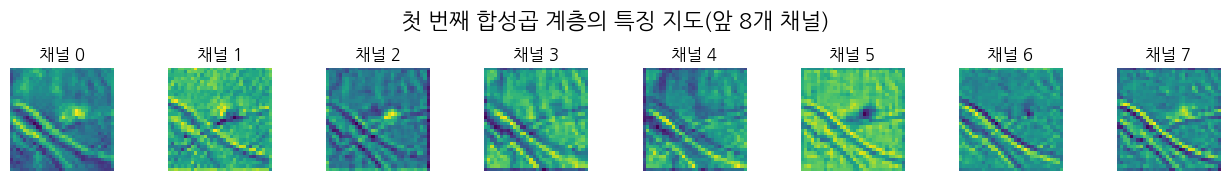

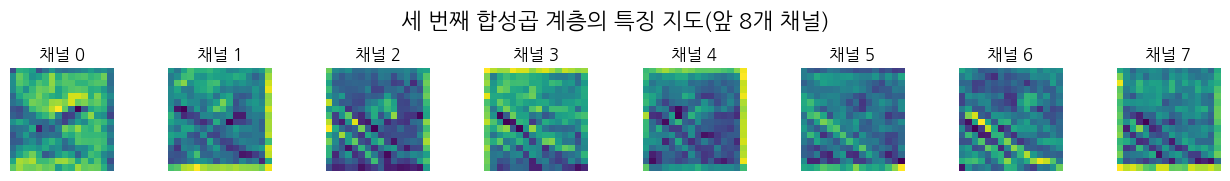

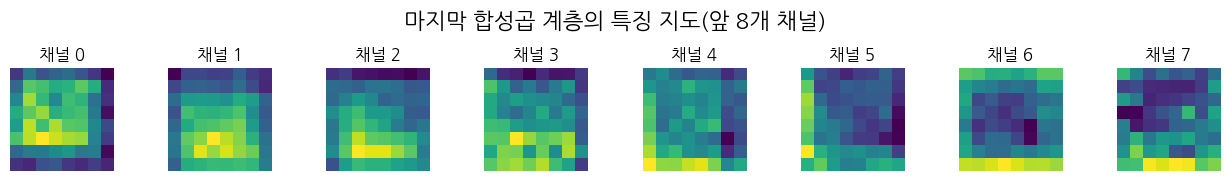

In [24]:
import matplotlib.pyplot as plt

sample_index = 0                        # 배치에서 살펴볼 샘플 하나 선택
for name, fmap in feature_maps.items():
    # fmap[sample_index]: (C, H, W) - 앞 8개 채널만 골라 시각화
    viz.plot_feature_map(
        fmap[sample_index][:8], title=f'{name} 계층의 특징 지도(앞 8개 채널)',
    )
    plt.show()

---

# 연습 문제 풀이

## 연습 문제 1

> 콜백 함수 `data_inspect_hook()`을 수정해 `MiniVGGNetBN` 모델에서 각 계층 출력 데이터의
> 최댓값과 최솟값을 출력해 보자. 그리고 출력에 가까운 계층일수록 이 값의 범위가 어떻게
> 변하는지 관찰해 보자.

In [25]:
# 계층 이름을 함께 담기 위해 클로저로 만든다(7.1절 패턴)
range_log = {}


def make_range_hook(name):
    def hook(module, inputs, output):
        range_log[name] = (output.min().item(), output.max().item())
    return hook


common.set_seed(SEED, deterministic=True)
model = MiniVGGNetBN()
# 여섯 개의 합성곱 계층을 순서대로 모은다
conv_layers = [(f'합성곱 {i + 1}', m) for i, m in enumerate(
    m for m in model.modules() if isinstance(m, nn.Conv2d))]

handles = [layer.register_forward_hook(make_range_hook(name))
           for name, layer in conv_layers]

inputs, _ = next(iter(train_loader))
model.eval()
with torch.no_grad():
    model(inputs)
for handle in handles:
    handle.remove()

print(f"{'계층':<12}{'최솟값':>12}{'최댓값':>12}{'범위':>12}")
print('-' * 48)
for name, _ in conv_layers:
    lo, hi = range_log[name]
    print(f'{name:<12}{lo:>12.4f}{hi:>12.4f}{hi - lo:>12.4f}')

계층                   최솟값         최댓값          범위
------------------------------------------------
합성곱 1            -1.5529      1.5467      3.0996
합성곱 2            -0.6165      0.7492      1.3658
합성곱 3            -0.3021      0.3108      0.6129
합성곱 4            -0.1002      0.1089      0.2090
합성곱 5            -0.0462      0.0571      0.1033
합성곱 6            -0.0252      0.0272      0.0524


### 풀이 해설 — 연습 문제 1

`data_inspect_hook()`에서 `mean()`, `std()`를 `min()`, `max()`로 바꾸기만 하면 된다. 다만 계층
여섯 개를 한꺼번에 보려면 **어느 계층의 값인지 구분할 방법**이 필요하므로 클로저를 썼다.

출력의 범위는 **출력층에 가까울수록 넓어진다.** 합성곱 계층을 지날 때마다 값이 가중합으로
누적되기 때문이다. 이 모델은 합성곱 계층 뒤마다 배치 정규화가 값을 다시 표준 분포로 되돌리지만,
훅은 **배치 정규화 이전인 합성곱 계층의 출력**을 보므로 누적이 그대로 드러난다.

배치 정규화가 없었다면 이 범위가 훨씬 빠르게 벌어졌을 것이다. 8-2절이 말한 "가중치 초기화의
늪"과 기울기 폭주가 바로 이 누적에서 온다.

## 연습 문제 2

> CIFAR-10 샘플 하나에 해당하는 입력 텐서를 무작위 값으로 만들고 순전파와 역전파를 1회
> 실행하면서, `MiniVGGNetBN` 모델의 모든 합성곱 계층별 **가중치 기울기의 평균**을 출력해 보자.
>
> 힌트: 계층 사이를 오가는 오차 신호가 아니라 파라미터의 기울기를 봐야 한다.

In [26]:
# 파라미터의 기울기이므로 모듈 훅이 아니라 '텐서 훅'(register_hook)을 써야 한다
grad_means = {}


def make_grad_mean_hook(name):
    def hook(grad):
        grad_means[name] = grad.mean().item()
    return hook


common.set_seed(SEED, deterministic=True)
model = MiniVGGNetBN()
conv_layers = [(f'합성곱 {i + 1}', m) for i, m in enumerate(
    m for m in model.modules() if isinstance(m, nn.Conv2d))]

# 가중치 텐서에 직접 훅을 등록한다
handles = [layer.weight.register_hook(make_grad_mean_hook(name))
           for name, layer in conv_layers]

# 무작위 입력 텐서 하나로 순전파와 역전파를 1회 실행
torch.manual_seed(SEED)
random_input = torch.randn(1, 3, 32, 32)
random_target = torch.tensor([3])

model.train()
model.zero_grad()
loss = nn.CrossEntropyLoss()(model(random_input), random_target)
loss.backward()

for handle in handles:
    handle.remove()

print(f"{'계층':<12}{'가중치 기울기 평균':>22}")
print('-' * 34)
for name, _ in conv_layers:
    print(f'{name:<12}{grad_means[name]:>22.3e}')

계층                      가중치 기울기 평균
----------------------------------
합성곱 1                   -1.062e-02
합성곱 2                   -1.954e-03
합성곱 3                   -1.342e-03
합성곱 4                    4.669e-04
합성곱 5                    2.886e-05
합성곱 6                   -2.607e-04


### 풀이 해설 — 연습 문제 2

**핵심은 어떤 훅을 고르느냐다.** [표 1]에서 세 가지를 견주면 답이 나온다.

- `register_full_backward_hook()`은 **모듈 훅**이라 계층 사이를 오가는 오차 신호
  (`grad_inputs`, `grad_outputs`)를 준다. 파라미터의 기울기가 아니다.
- `register_hook()`은 **텐서 훅**이다. 가중치 텐서에 직접 걸면 그 텐서의 기울기를 받는다.

따라서 `layer.weight.register_hook(...)`이 맞다. 4.1절에서 설명한 두 기울기의 차이를 확인하는
문제다.

훅을 쓰지 않고 `backward()` 뒤에 `layer.weight.grad.mean()`을 읽어도 같은 값이 나온다
(5.6절 참고). **이 문제에서 훅이 주는 이점은 없다.** 그래도 훅으로 풀어 보는 이유는, 두 훅이
서로 다른 대상을 본다는 것을 손으로 확인하기 위해서다.

배치 크기가 1이라 기울기 평균이 매우 작게 나온다. 부호가 계층마다 엇갈리는 것도 자연스럽다.
평균은 상쇄가 일어나므로 크기를 보려면 노름이나 절댓값의 평균이 더 낫다.

## 연습 문제 3

> `register_forward_pre_hook()`으로 첫 번째 합성곱 계층에 훅을 걸어, 계층에 **들어가기 직전**의
> 입력 텐서의 형태와 값 범위를 출력해 보자. `register_forward_hook()`으로 같은 계층을
> 관찰했을 때와 무엇이 다른지 설명해 보자.

In [27]:
# register_forward_pre_hook의 서명은 (module, inputs) - output이 없다
def pre_hook(module, inputs):
    x = inputs[0]
    print(f'  [pre]  입력 {tuple(x.shape)}, 범위 [{x.min():.3f}, {x.max():.3f}]')


def post_hook(module, inputs, output):
    x, y = inputs[0], output
    print(f'  [post] 입력 {tuple(x.shape)}, 범위 [{x.min():.3f}, {x.max():.3f}]')
    print(f'         출력 {tuple(y.shape)}, 범위 [{y.min():.3f}, {y.max():.3f}]')


common.set_seed(SEED, deterministic=True)
model = MiniVGGNetBN()
first_conv = model.features[0][0]

h1 = first_conv.register_forward_pre_hook(pre_hook)
h2 = first_conv.register_forward_hook(post_hook)

inputs, _ = next(iter(train_loader))
model.eval()
print('첫 번째 합성곱 계층')
with torch.no_grad():
    model(inputs)

h1.remove()
h2.remove()

첫 번째 합성곱 계층
  [pre]  입력 (64, 3, 32, 32), 범위 [-1.000, 1.000]
  [post] 입력 (64, 3, 32, 32), 범위 [-1.000, 1.000]
         출력 (64, 32, 32, 32), 범위 [-1.553, 1.547]


### 풀이 해설 — 연습 문제 3

두 훅의 차이는 세 가지다.

1. **서명이 다르다.** `register_forward_pre_hook()`의 콜백은 `(module, inputs)` 두 개만 받는다.
   계층 연산 전이라 아직 출력이 없기 때문이다.
2. **실행 순서가 다르다.** 출력에서 보듯 `[pre]`가 먼저, `[post]`가 나중에 찍힌다.
3. **바꿀 수 있는 대상이 다르다.** 순전파 사전 훅이 값을 반환하면 **계층의 입력**이 바뀌고,
   순전파 훅이 값을 반환하면 **계층의 출력**이 바뀐다.

입력 텐서의 형태와 값은 두 훅에서 같다. 같은 계층의 같은 입력이기 때문이다. 그래서 **단순히
입력을 들여다보는 것이 목적이라면 둘 중 아무거나 써도 된다.** 사전 훅이 꼭 필요한 경우는
계층에 들어가는 값을 **가로채 바꿔야** 할 때다.

## 연습 문제 4 [도전 문제]

> `MiniVGGNetBN` 모델의 첫 번째, 세 번째, 마지막 합성곱 계층이 출력하는 특징 지도 중 각각
> 여덟 개씩 골라 이미지 파일로 저장해 보고, 특징 지도가 나타내는 바를 설명해 보자.

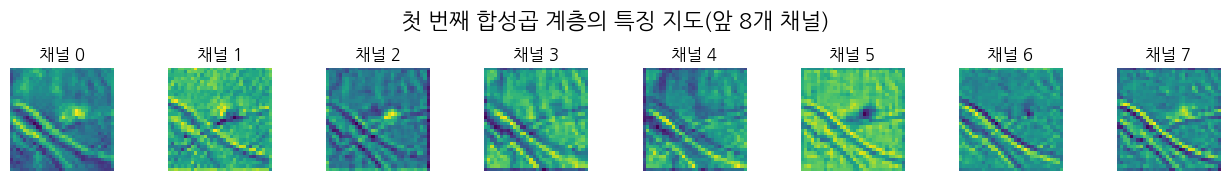

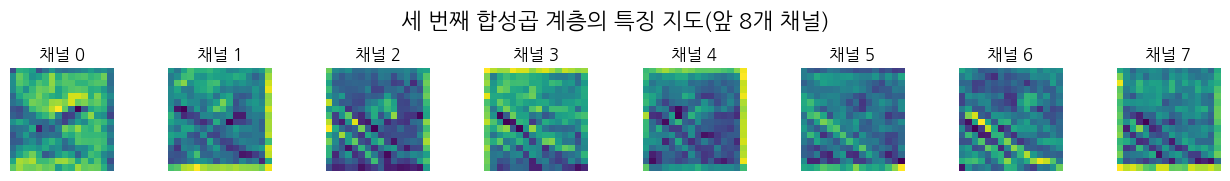

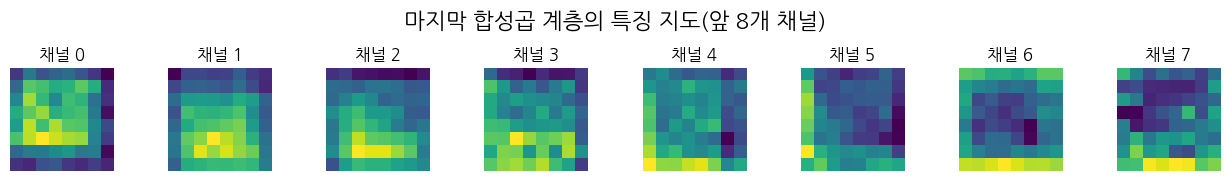


저장된 파일: ['pytorch_hook_01.png', 'pytorch_hook_02.png', 'pytorch_hook_03.png']


In [28]:
# viz.configure(save_grayscale=True)로 설정하면 그림이 회색조 PNG 파일로도 저장된다
import os

FIGURE_DIR = 'figures'
os.makedirs(FIGURE_DIR, exist_ok=True)
viz.configure(save_grayscale=True, output_dir=FIGURE_DIR,
              notebook_name='pytorch_hook')

sample_index = 0
for name, fmap in feature_maps.items():
    viz.plot_feature_map(
        fmap[sample_index][:8], title=f'{name} 계층의 특징 지도(앞 8개 채널)',
    )
    plt.show()

# 원래 설정으로 되돌린다(이후 셀에서 파일이 쌓이지 않도록)
viz.configure(save_grayscale=False)
print()
print('저장된 파일:', sorted(os.listdir(FIGURE_DIR)))

### 풀이 해설 — 연습 문제 4

특징 지도 수집은 [코드 11]의 클로저 훅으로 이미 해 두었다. 저장은 `viz.configure()`로
`save_grayscale=True`를 켜 두면 `viz.plot_feature_map()`이 그림을 그리면서 함께 처리한다.

**특징 지도가 나타내는 바**는 계층마다 다르다.

- **첫 번째 합성곱 계층**(32x32) — 원본 이미지의 윤곽이 그대로 보인다. 채널마다 밝은 영역이
  다른데, 어떤 채널은 가로 경계를, 어떤 채널은 세로 경계를, 어떤 채널은 특정 색 영역을
  강조한다. 5장에서 필터가 저수준 특징을 잡아낸다고 배운 그대로다.
- **세 번째 합성곱 계층**(16x16) — 해상도가 절반으로 줄고 무늬가 뭉툭해진다. 개별 경계가 아니라
  그것들이 모인 덩어리가 보인다.
- **마지막 합성곱 계층**(8x8) — 사람 눈으로는 무엇을 뜻하는지 알기 어렵다. 몇 개의 밝은 점만
  남는데, 이 점들이 '고양이의 귀 같은 것이 여기 있다'처럼 **고수준 특징의 존재 여부**를
  나타낸다.

**주의할 점이 하나 있다.** 여기서 쓴 모델은 학습을 거치지 않은 모델이라 필터가 무작위 값이다.
그래서 "의미 있는 특징"이라기보다 무작위 필터가 만든 무늬에 가깝다. 학습을 마친 모델로 같은
실험을 하면 훨씬 또렷한 패턴을 볼 수 있다.

## 연습 문제 5 [도전 문제]

> 6.1절을 참고해 `MiniVGGNetBN`의 **마지막 VGG 블록 전체의 출력을 0으로 만드는** 훅을 등록한 뒤
> 평가 데이터셋의 분류 정확도를 측정해 보자.

In [29]:
# 비교가 의미 있으려면 어느 정도 학습된 모델이 필요하다(3 에포크만 짧게 학습)
import torch.optim as optim

EPOCHS_SHORT = 3

common.set_seed(SEED, deterministic=True)
trained = MiniVGGNetBN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(trained.parameters(), lr=1e-3)

for epoch in range(1, EPOCHS_SHORT + 1):
    trained.train()
    for batch_inputs, batch_targets in train_loader:
        batch_inputs = batch_inputs.to(device)
        batch_targets = batch_targets.to(device)
        optimizer.zero_grad()
        loss = criterion(trained(batch_inputs), batch_targets)
        loss.backward()
        optimizer.step()
    print(f'{epoch}/{EPOCHS_SHORT} 에포크 학습 완료')

# common.get_accuracy()는 (정확도(%), 정답 수, 전체 수)를 반환한다
base_acc, _, _ = common.get_accuracy(trained, test_loader, device)
print(f'훅 없이 측정한 평가 정확도: {base_acc:.2f}%')

1/3 에포크 학습 완료


2/3 에포크 학습 완료


3/3 에포크 학습 완료


훅 없이 측정한 평가 정확도: 68.37%


In [30]:
# 마지막 VGG 블록의 출력을 0으로 만드는 훅
def zero_out_hook(module, inputs, output):
    return torch.zeros_like(output)


handle = trained.features[2].register_forward_hook(zero_out_hook)
zero_acc, _, _ = common.get_accuracy(trained, test_loader, device)
handle.remove()

restored_acc, _, _ = common.get_accuracy(trained, test_loader, device)
print(f'마지막 블록을 0으로 만든 정확도: {zero_acc:.2f}%')
print(f'훅을 제거한 뒤 정확도: {restored_acc:.2f}%')
print()
print(f'정확도 하락: {base_acc - zero_acc:.2f}%p')
print(f'무작위 추측(10%)과의 차이: {zero_acc - 10.0:.2f}%p')

마지막 블록을 0으로 만든 정확도: 10.00%
훅을 제거한 뒤 정확도: 68.37%

정확도 하락: 58.37%p
무작위 추측(10%)과의 차이: 0.00%p


### 풀이 해설 — 연습 문제 5

훅이 `torch.zeros_like(output)`을 반환하면 그 값이 계층의 출력을 대체한다(6.1절). 마지막 VGG
블록 전체(`features[2]`)에 걸었으므로, 분류기는 **언제나 0으로 채워진 텐서**를 받는다.

결과는 무작위 추측(10%) 수준으로 떨어진다. 입력이 무엇이든 분류기가 받는 값이 같으므로
모델은 늘 같은 클래스를 답할 수밖에 없다. **완전히 예상 가능한 결과이고, 그것이 이 문제의
요지다.**

여기서 눈여겨볼 것은 결과가 아니라 **방법**이다.

1. **모델 코드를 한 글자도 고치지 않았다.** 계층을 지우고 다시 만들 필요가 없다.
2. **되돌리기가 `remove()` 한 줄이다.** 실제로 훅을 제거한 뒤 정확도가 원래대로 돌아온다.
3. **모듈 단위로 걸 수 있다.** `features[2]`는 `nn.Sequential`이지 단일 계층이 아니다. 2.2절에서
   "모듈은 모델 객체 자체도 포함한다"고 한 것이 이런 뜻이다.

이 기법은 **절제 실험**(ablation study)의 가장 값싼 형태다. 어떤 계층이나 블록이 성능에 실제로
기여하는지 확인할 때, 모델을 다시 만들고 학습할 필요 없이 훅 하나로 '없는 셈 치고' 돌려 볼 수
있다. 다만 **학습된 모델에서 그 블록을 빼고 다시 학습한 것과는 다르다.** 뒤 계층이 그 블록의
출력에 맞춰 이미 학습된 상태이기 때문이다. 절제 실험의 결과를 읽을 때 늘 주의해야 하는 지점이다.

## 연습 문제 6 [도전 문제]

> 6.2절의 `clip_grad_hook()`을 `MiniVGGNet`(배치 정규화 없음)의 모든 파라미터에 등록하고
> 학습해 보자. 등록하지 않았을 때와 학습 곡선이 어떻게 달라지는지 관찰하고, 그 결과를
> [표 2]의 기울기 노름과 함께 해석해 보자.

In [31]:
# 짧게(3 에포크) 학습해 초반 곡선을 비교한다
def train_short(max_norm=None, epochs=EPOCHS_SHORT, lr=1e-3):
    common.set_seed(SEED, deterministic=True)
    model = MiniVGGNet().to(device)
    handles = []
    if max_norm is not None:
        handles = [p.register_hook(make_clip_grad_hook(max_norm))
                   for p in model.parameters()]
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    losses = []
    for epoch in range(1, epochs + 1):
        model.train()
        loss_sum, sample_size = 0.0, 0
        for batch_inputs, batch_targets in train_loader:
            batch_inputs = batch_inputs.to(device)
            batch_targets = batch_targets.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_inputs), batch_targets)
            loss.backward()
            optimizer.step()
            loss_sum += loss.item() * batch_inputs.size(0)
            sample_size += batch_inputs.size(0)
        losses.append(loss_sum / sample_size)
    for handle in handles:
        handle.remove()
    acc, _, _ = common.get_accuracy(model, test_loader, device)
    return losses, acc


plain_losses, plain_acc = train_short(max_norm=None)       # 클리핑 없음
clip_losses, clip_acc = train_short(max_norm=1.0)         # 기준 1.0(걸리지 않음)
tight_losses, tight_acc = train_short(max_norm=0.02)      # 기준 0.02(실제로 걸림)

print(f"{'에포크':<8}{'클리핑 없음':>14}{'기준 1.0':>14}{'기준 0.02':>14}")
print('-' * 52)
for i, (a, b, c) in enumerate(zip(plain_losses, clip_losses, tight_losses), start=1):
    print(f'{i:<8}{a:>14.4f}{b:>14.4f}{c:>14.4f}')
print()
print(f'평가 정확도  클리핑 없음 {plain_acc:.2f}% / '
      f'기준 1.0 {clip_acc:.2f}% / 기준 0.02 {tight_acc:.2f}%')

에포크             클리핑 없음        기준 1.0       기준 0.02
----------------------------------------------------
1               1.7715        1.7872        1.7783
2               1.3333        1.3518        1.3593
3               1.1139        1.1390        1.1534

평가 정확도  클리핑 없음 65.14% / 기준 1.0 66.62% / 기준 0.02 64.89%


### 풀이 해설 — 연습 문제 6

**결과를 읽을 때 [표 2]를 함께 봐야 한다.** `MiniVGGNet`의 기울기 노름은 첫 번째 합성곱 계층에서
0.0003 수준이고, 파라미터를 통틀어 가장 큰 것도 0.09 남짓이다. 클리핑 기준 1.0에 한참 못 미친다.

그래서 **기준 1.0으로는 클리핑이 한 번도 걸리지 않는다.** 학습 곡선이 클리핑 없는 경우와
똑같이 나오는 것이 자연스럽고, 그것이 이 문제가 노린 바다. 기울기 클리핑은 **기울기 폭주**를
막는 장치인데 `MiniVGGNet`의 문제는 정반대인 **기울기 소실**이기 때문이다.

기준을 0.02까지 낮추면 그제야 클리핑이 실제로 작동한다. 이때는 오히려 **학습이 느려진다.**
가뜩이나 작은 기울기를 더 깎아 버리니 파라미터가 움직이는 폭이 줄기 때문이다.

6장에서 기울기 클리핑을 순환 신경망과 함께 배운 이유가 여기서 드러난다. 순환 신경망은 같은
가중치를 시간 방향으로 반복해 곱하므로 기울기가 쉽게 폭주한다. 합성곱 신경망, 특히 배치
정규화를 쓴 모델에서는 그럴 일이 드물다.

**도구를 아는 것과 그 도구가 필요한 상황을 아는 것은 다르다.** 그리고 **훅을 걸었는데 아무 일도
일어나지 않을 때 훅이 잘못된 것인지 조건이 잘못된 것인지 구분하는 것**도 이 문제의 수확이다.
6.1절의 `clamp` 범위와 똑같은 함정이다.


## 연습 문제 7

> 5.6절의 [코드 10]으로 얻은 기울기가 [코드 9]의 `.grad`로 얻은 기울기와 같은 값인지 직접
> 확인해 보자. 그런 다음 `model.zero_grad()`를 부르지 않고 `backward()`를 **두 번** 실행하면
> 두 방법의 결과가 어떻게 달라지는지 관찰하고, 그 이유를 설명해 보자.

In [32]:
# backward()를 두 번 실행하면서 훅이 본 값과 .grad에 쌓인 값을 비교한다
torch.manual_seed(SEED)
model = StackedConvBN(12)
first_conv = next(m for m in model.modules() if isinstance(m, nn.Conv2d))

hook_seen = []


def record_hook(grad):
    hook_seen.append(grad.norm().item())


handle = first_conv.weight.register_hook(record_hook)

model.train()
model.zero_grad()
for step in (1, 2):
    out = model(test_input)
    loss = F.adaptive_avg_pool2d(out, 1).flatten().sum()
    loss.backward()
    print(f'{step}회째 backward()')
    print(f'  훅이 본 기울기 노름   : {hook_seen[-1]:.6f}')
    print(f'  .grad에 쌓인 노름     : {first_conv.weight.grad.norm().item():.6f}')

handle.remove()

1회째 backward()
  훅이 본 기울기 노름   : 2.711730
  .grad에 쌓인 노름     : 2.711730
2회째 backward()
  훅이 본 기울기 노름   : 2.711730
  .grad에 쌓인 노름     : 5.423460


### 풀이 해설 — 연습 문제 7

**첫 번째 `backward()`에서는 두 값이 같다.** `.grad`가 비어 있었으므로 이번에 계산된 기울기가
그대로 저장된다. [코드 10]에서 두 방법의 차이가 0으로 나온 이유다.

**두 번째 `backward()`에서 갈라진다.**

- **훅이 본 값**은 이번에 계산된 기울기 하나다. 입력이 같으므로 첫 번째와 같은 값이다.
- **`.grad`에 쌓인 값**은 두 번의 기울기가 **더해진** 값이라 노름이 약 두 배가 된다.

파이토치는 `backward()`를 부를 때마다 기울기를 `.grad`에 **누적**한다. 학습 루프에서
`optimizer.zero_grad()`를 매번 부르는 이유가 이것이다.

**여기서 두 방법의 성격 차이가 분명해진다.**

| | `.grad` | 텐서 훅 |
|---|---|---|
| 보는 것 | 지금까지 쌓인 **총합** | 이번에 계산된 **기여 하나** |
| 유용한 때 | 최적화 직전의 최종 기울기 | 기울기 누적을 쓰거나, 한 파라미터가 여러 경로에서 기울기를 받을 때 |

배치를 나눠 여러 번 역전파한 뒤 한 번에 최적화하는 **기울기 누적**(gradient accumulation)을 쓸 때,
각 배치가 얼마나 기여했는지는 `.grad`로는 알 수 없고 훅으로만 볼 수 있다.

## 연습 문제 8 [도전 문제]

> 5.2절의 `StackedConvBN` 모델에서 **배치 정규화 계층만 모두 빼고** 5.3절의 실험을 다시 해 보자.

In [33]:
# 배치 정규화 없이 합성곱과 ReLU만 쌓은 모델
class StackedConvPlain(nn.Module):
    def __init__(self, num_blocks, channels=16):
        super().__init__()
        layers = [nn.Conv2d(3, channels, 3, padding=1, bias=False), nn.ReLU()]
        for _ in range(num_blocks - 1):
            layers.append(nn.Conv2d(channels, channels, 3, padding=1, bias=False))
            layers.append(nn.ReLU())
        self.features = nn.Sequential(*layers)

    def forward(self, x):
        return self.features(x)


torch.manual_seed(SEED)
plain_12 = StackedConvPlain(12)
torch.manual_seed(SEED)
plain_48 = StackedConvPlain(48)
torch.manual_seed(SEED)
plain_96 = StackedConvPlain(96)
plain_models = [plain_12, plain_48, plain_96]

print('배치 정규화 없음 - 값이 거의 같은 두 텐서에 대한 출력 유사도')
print(f'{"":>14s} | {"12-Conv":>12s} | {"48-Conv":>12s} | {"96-Conv":>12s}')
print('-' * 62)
plain_results = [measure_similarity(m, test_input, similar_input)
                 for m in plain_models]
print(f'{"유클리드 거리":>8s} | ' + ' | '.join(f'{d:>12.3e}' for d, _ in plain_results))
print(f'{"코사인 유사도":>8s} | ' + ' | '.join(f'{c:>12.6f}' for _, c in plain_results))

print()
print('(비교) 배치 정규화 있음')
bn_results = [measure_similarity(m, test_input, similar_input) for m in models]
print(f'{"유클리드 거리":>8s} | ' + ' | '.join(f'{d:>12.3e}' for d, _ in bn_results))
print(f'{"코사인 유사도":>8s} | ' + ' | '.join(f'{c:>12.6f}' for _, c in bn_results))

배치 정규화 없음 - 값이 거의 같은 두 텐서에 대한 출력 유사도
               |      12-Conv |      48-Conv |      96-Conv
--------------------------------------------------------------
 유클리드 거리 |    1.904e-08 |    0.000e+00 |    0.000e+00
 코사인 유사도 |     1.000000 |     0.000000 |     0.000000

(비교) 배치 정규화 있음
 유클리드 거리 |    7.275e-03 |    3.609e+00 |    1.002e+02
 코사인 유사도 |     1.000000 |     0.999205 |     0.400111


### 풀이 해설 — 연습 문제 8

**배치 정규화를 빼면 출력의 차이가 증폭되지 않는다.** 코사인 유사도가 깊이와 무관하게 1에
가깝게 유지된다. 8-3절이 말한 "배치 정규화 자체가 함정이 된다"가 사실임을 반대편에서 확인하는
셈이다.

이유는 8-3절 본문이 설명한 그대로다. **배치 정규화는 입력 텐서의 통계량으로 정규화하므로,
입력이 조금만 달라도 통계량이 어긋나 정규화 결과에 작은 차이가 생긴다.** 그 차이가 계층마다
되풀이되며 쌓인다. 배치 정규화가 없으면 통계량에 기대는 단계가 없으므로 이 증폭 경로 자체가
사라진다.

**그렇다고 배치 정규화를 빼는 것이 답은 아니다.** 유의할 점이 두 가지 있다.

1. **유클리드 거리의 절대값을 곧이곧대로 비교하면 안 된다.** 배치 정규화가 없으면 계층을 지날
   때마다 값의 크기 자체가 제멋대로 커지거나 작아진다. 출력의 규모가 다르므로 거리도 규모를
   따라 달라진다. 방향을 보는 **코사인 유사도** 쪽이 공정한 비교다.
2. **8-2절이 보인 이득이 사라진다.** 배치 정규화가 없으면 학습이 느려지고 기울기 소실이
   심해진다([표 2]). 이 실험은 배치 정규화를 빼라는 뜻이 아니라, **깊이가 어느 선을 넘으면
   배치 정규화만으로는 부족하다**는 것을 보이는 것이다. 그 답이 8-3절의 잔차 학습이다.